Q1. Train logistic regression on the churn table; print the confusion matrix and all five metrics. Write the
smoke-detector sentence: 'we catch _% of churners; _% of our alarms are real.'

In [1]:
#import libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
#load dataset
features = pd.read_csv("churn_features.csv")
X = features[["days_since_last_order", "order_velocity", "avg_order_value", "tenure_days", "avg_review_stars"]]
y = features["churned"]
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

Confusion Matrix:
 [[1399    0]
 [   0  101]]


Text(0.5, 1.0, 'Confusion Matrix')

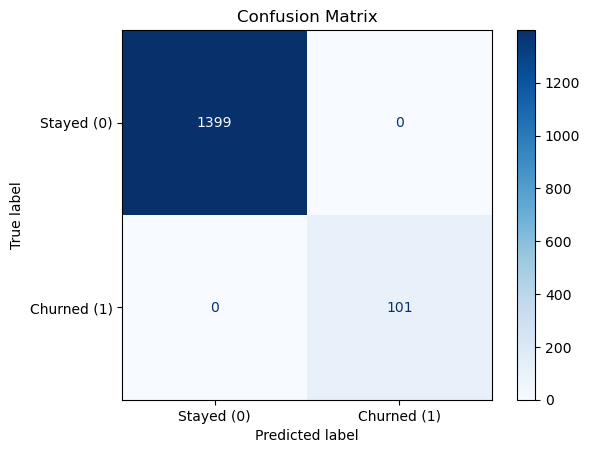

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:\n", cm)
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = model.predict(X_test)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues", display_labels=["Stayed (0)", "Churned (1)"]
)
disp.ax_.set_title("Confusion Matrix")

In [5]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 0.9999999999999999


In [6]:
# Smoke-detector sentence
recall_pct = recall_score(y_test, y_pred) * 100
precision_pct = precision_score(y_test, y_pred) * 100
print(f"We catch {recall_pct:.1f}% of churners; {precision_pct:.1f}% of our alarms are real.")

We catch 100.0% of churners; 100.0% of our alarms are real.


Q2. Sweep the threshold from 0.1 to 0.9; plot precision and recall vs threshold; mark where coupons (Rs. 200) vs
churn losses (Rs. 4,000) balance.

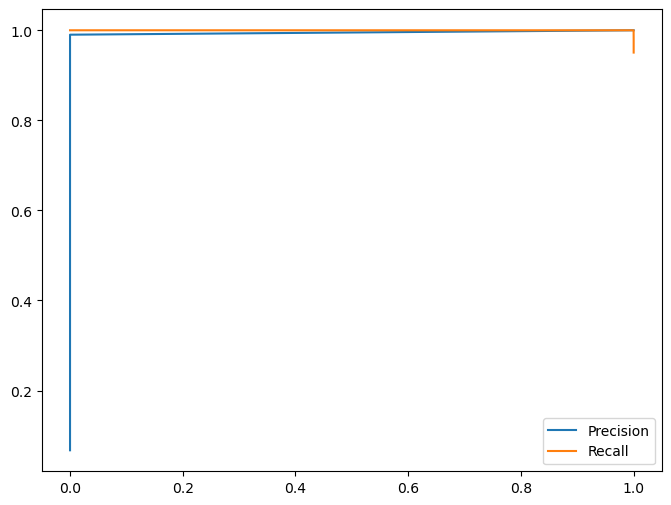

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.legend()
plt.show()

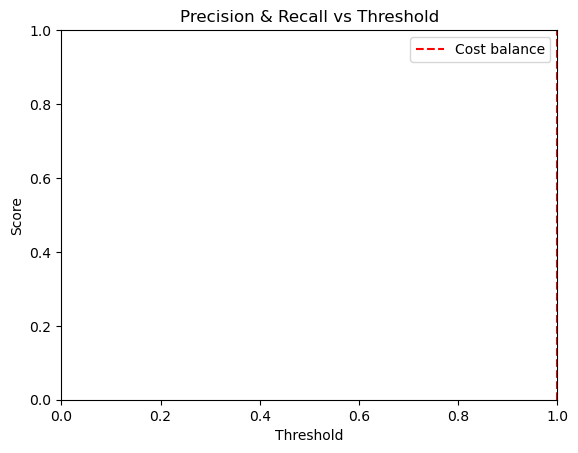

In [14]:
balance_threshold = thresholds[np.argmax(recalls[:-1] * 20 + precisions[:-1])]
plt.axvline(balance_threshold, color="red", linestyle="--", label="Cost balance")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision & Recall vs Threshold")
plt.show()

Q3. Add KNN (scaled!, k ˛ {1, 5, 25, 101}) and note the bias-variance story in the validation scores.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for k in [1, 5, 25, 101]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy")
    print(f"K={k}: mean={scores.mean():.3f}, std={scores.std():.3f}")

K=1: mean=0.996, std=0.002
K=5: mean=0.997, std=0.002
K=25: mean=0.996, std=0.002
K=101: mean=0.996, std=0.002


Q4. Compare class_weight='balanced' vs unweighted on recall — one line of code, measurable jump.

In [18]:
model_unweighted = LogisticRegression(max_iter=1000)
model_unweighted.fit(X_train, y_train)
print("Recall (unweighted):", recall_score(y_test, model_unweighted.predict(X_test)))
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train, y_train)
print("Recall (balanced):", recall_score(y_test, model_balanced.predict(X_test)))

Recall (unweighted): 1.0
Recall (balanced): 1.0
